# Federated Learning Pipeline with Dataset Analysis
This notebook provides a comprehensive pipeline for analyzing air quality datasets and running federated learning simulations.

In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime
import yaml


## 1. Dataset Parsing Function

In [39]:
def parse_dataset_name(filename):
    parts = filename.split('_')
    interval = parts[2]
    year = parts[3]
    place = ' '.join(parts[7:-2])
    return {'interval': interval, 'year': year, 'place': place}

# Example usage
file_name = "Raw_data_15Min_2017_site_125_Punjabi_Bagh_Delhi_DPCC_15Min.csv"
parsed_info = parse_dataset_name(file_name)
parsed_info

{'interval': '15Min', 'year': '2017', 'place': 'Bagh Delhi'}

## 2. Data Analysis Function

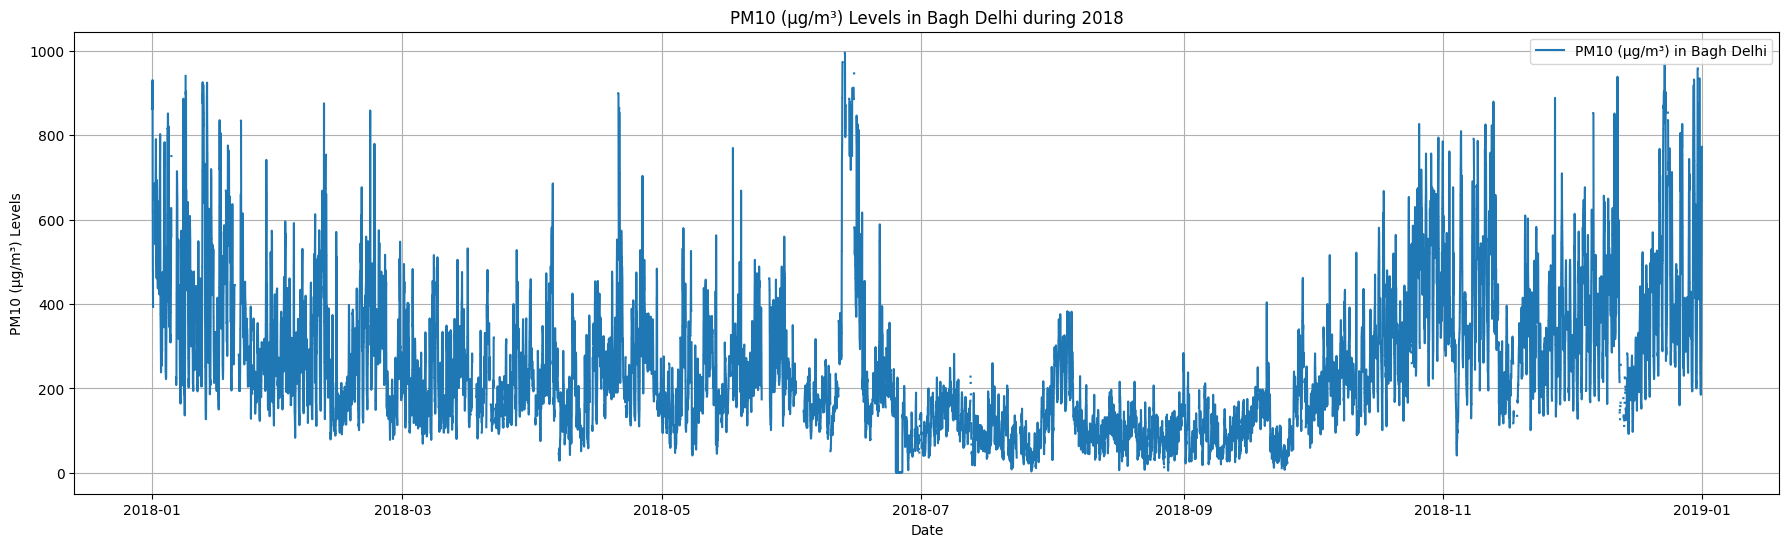

In [40]:
def analyze_pollutants(datasets, year, pollutant, place):
    combined_data = []
    for dataset in datasets:
        # print( dataset)
        info = parse_dataset_name(os.path.basename(dataset))
        # print(info)
        data = pd.read_csv(dataset)
        # print( data.columns)
        if info['year'] == str(year) and place.lower() in info['place'].lower():
            data = pd.read_csv(dataset)
            # print( data.columns)
            if pollutant in data.columns:
                data['datetime'] = pd.to_datetime(data['Timestamp'])
                combined_data.append(data[['datetime', pollutant]])
                

    if combined_data:
        combined_df = pd.concat(combined_data).sort_values('datetime')
        plt.figure(figsize=(22, 6))
        plt.plot(combined_df['datetime'], combined_df[pollutant], label=f'{pollutant} in {place}')
        plt.xlabel('Date')
        plt.ylabel(f'{pollutant} Levels')
        plt.title(f'{pollutant} Levels in {place} during {year}')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print(f"No data found for {pollutant} in {place} during {year}.")

# Example usage
datasets = ["Dataset_Dehli/Raw_data_15Min_2018_site_125_Punjabi_Bagh_Delhi_DPCC_15Min.csv"]
analyze_pollutants(datasets, 2018, 'PM10 (µg/m³)', 'Bagh Delhi')

## 3. Trend Analysis for Time-Series Suitability

In [41]:
def trend_analysis(data, pollutant):
    if pollutant in data.columns:
        data['datetime'] = pd.to_datetime(data['Timestamp'])
        data = data.sort_values('datetime')
        data = data.dropna(subset=[pollutant])  # Remove rows with NaN values in the pollutant column
        X = np.arange(len(data)).reshape(-1, 1)
        y = data[pollutant].values.reshape(-1, 1)
        model = LinearRegression()
        model.fit(X, y)
        trend = model.coef_[0][0]
        print(f"Trend for {pollutant}: {trend}")
        return abs(trend) > 0.01  # Example threshold
    else:
        print(f"Pollutant {pollutant} not found in data.")
        return False

# Example usage
dataset = pd.read_csv("Dataset_Dehli/Raw_data_15Min_2017_site_125_Punjabi_Bagh_Delhi_DPCC_15Min.csv")
trend_analysis(dataset, 'PM10 (µg/m³)')


Trend for PM10 (µg/m³): 0.01020177978514372


np.True_

## find out the proper model for each pollutant

In [42]:
import pandas as pd

# Import CSV and put into a DataFrame
file_path = './Dataset_Dehli/Raw_data_15Min_2017_site_108_Aya_Nagar_Delhi_IMD_15Min.csv'  # Update with your file path

df = pd.read_csv(file_path)

# Parse the timestamp column
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Set the timestamp as the index
df.set_index('Timestamp', inplace=True)

# Display the first few rows of the dataframe
print(df.head())


                     PM2.5 (µg/m³)  PM10 (µg/m³)  NO (µg/m³)  NO2 (µg/m³)  \
Timestamp                                                                   
2017-01-01 00:00:00            NaN           NaN         NaN          NaN   
2017-01-01 00:15:00            NaN           NaN         NaN          NaN   
2017-01-01 00:30:00            NaN           NaN         NaN          NaN   
2017-01-01 00:45:00            NaN           NaN         NaN          NaN   
2017-01-01 01:00:00            NaN           NaN         NaN          NaN   

                     NOx (ppb)  NH3 (µg/m³)  SO2 (µg/m³)  CO (mg/m³)  \
Timestamp                                                              
2017-01-01 00:00:00        NaN          NaN          NaN         NaN   
2017-01-01 00:15:00        NaN          NaN          NaN         NaN   
2017-01-01 00:30:00        NaN          NaN          NaN         NaN   
2017-01-01 00:45:00        NaN          NaN          NaN         NaN   
2017-01-01 01:00:00        N

In [43]:
!pip install nbformat --upgrade


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


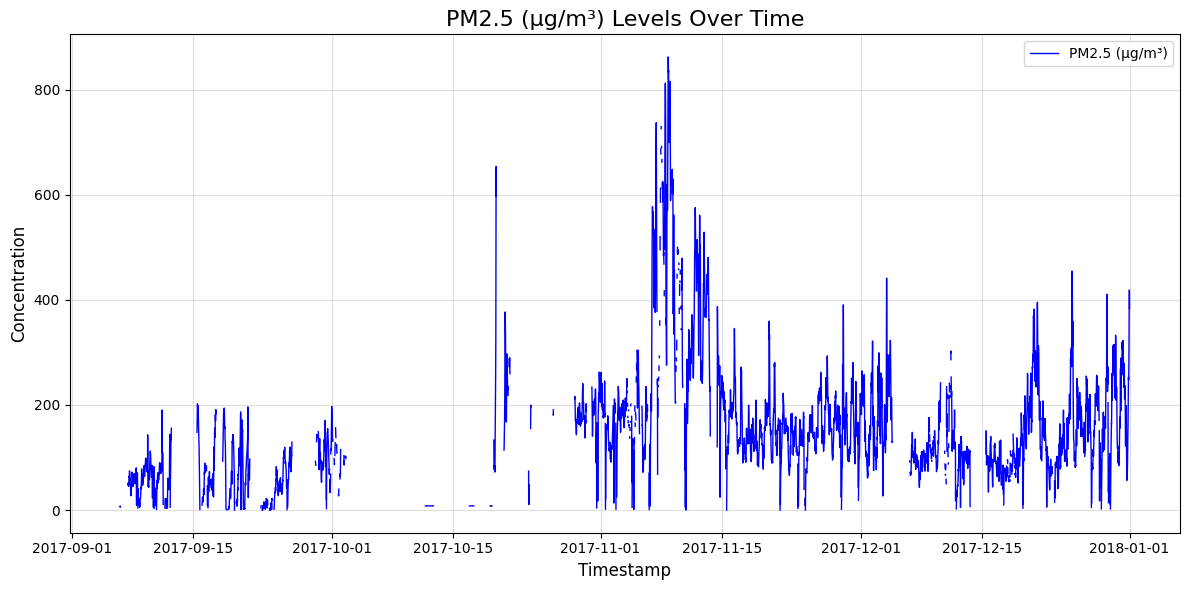

In [44]:
import matplotlib.pyplot as plt

# Select a pollutant
pollutant = "PM2.5 (µg/m³)"  # Replace with the desired column name


plt.figure(figsize=(12, 6))
plt.plot(df.index, df[pollutant], label=pollutant, color='blue', linewidth=1)

# Add title and labels
plt.title(f"{pollutant} Levels Over Time", fontsize=16)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Concentration", fontsize=12)

# Add grid and legend
plt.grid(alpha=0.4)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [45]:
from tpot import TPOTRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df_clean = df[[pollutant]].dropna()  
df_clean['timestamp_numeric'] = df_clean.index.factorize()[0]  # Convert timestamps to numeric

# Define X (features) and y (target)
X = df_clean[['timestamp_numeric']]
y = df_clean[pollutant]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train TPOT
tpot = TPOTRegressor(generations=5, population_size=20, verbosity=2, random_state=42)
tpot.fit(X_train, y_train)

# Evaluate the model
y_pred = tpot.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

# Save the best pipeline
tpot.export('best_tpot_pipeline.py')

# Display actual vs. predicted values
result_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
print(result_df.head())


c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\tpot\builtins\__init__.py:36: UserWarning: Warning: optional dependency `torch` is not available. - skipping import of NN models.
  warnings.warn("Warning: optional dependency `torch` is not available. - skipping import of NN models.")


is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor


c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\sklearn\base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\sklearn\base.py:1270: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
                                                                             
Generation 1 - Current best internal CV score: -392.92862306027746
                                                                             
Generation 2 - Current best internal CV score: -

In [46]:
import joblib
joblib.dump(tpot.fitted_pipeline_, 'best_tpot_model.pkl')


['best_tpot_model.pkl']

In [47]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Prepare the time series data
series = df[pollutant].dropna()
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# ARIMA Model
arima_model = ARIMA(train, order=(5, 1, 0))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))
arima_mse = mean_squared_error(test, arima_pred)

# SARIMA Model
sarima_model = SARIMAX(train, order=(5, 1, 0), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(test))
sarima_mse = mean_squared_error(test, sarima_pred)

# Compare results
print(f"ARIMA MSE: {arima_mse}")
print(f"SARIMA MSE: {sarima_mse}")

# Display predictions
result_df = pd.DataFrame({
    'Actual': test,
    'ARIMA_Predicted': arima_pred,
    'SARIMA_Predicted': sarima_pred
})
print(result_df.head())


c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\st

ARIMA MSE: 15366.16208302861
SARIMA MSE: 14850.001744266296
                     Actual  ARIMA_Predicted  SARIMA_Predicted
2017-12-17 04:30:00   57.60              NaN               NaN
2017-12-17 04:45:00   55.25              NaN               NaN
2017-12-17 05:00:00   51.63              NaN               NaN
2017-12-17 05:15:00   47.44              NaN               NaN
2017-12-17 05:30:00   50.91              NaN               NaN


c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\DELL\AppData\Local\Temp\ipykernel_2052\2344857976.py:27: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  result_df = pd.DataFrame({


In [48]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# Preprocess the dataset
def preprocess_data(df, pollutant, split_ratio=0.8):
    df = df[[pollutant]].dropna()
    train_size = int(len(df) * split_ratio)
    train, test = df.iloc[:train_size], df.iloc[train_size:]
    return train, test

# ARIMA model
def run_arima(train, test):
    model = ARIMA(train, order=(5, 1, 0))
    fit = model.fit()
    predictions = fit.forecast(steps=len(test))
    mse = mean_squared_error(test, predictions)
    return predictions, mse

# SARIMA model
def run_sarima(train, test):
    model = SARIMAX(train, order=(5, 1, 0), seasonal_order=(1, 1, 1, 12))
    fit = model.fit(disp=False)
    predictions = fit.forecast(steps=len(test))
    mse = mean_squared_error(test, predictions)
    return predictions, mse

# Prophet model
def run_prophet(train, test):
    train_prophet = train.reset_index()
    train_prophet.columns = ['ds', 'y']
    model = Prophet()
    model.fit(train_prophet)
    future = pd.DataFrame(test.index).rename(columns={test.index.name: 'ds'})
    forecast = model.predict(future)
    predictions = forecast['yhat'].values
    mse = mean_squared_error(test, predictions)
    return predictions, mse

# GRU model
def run_gru(train, test, sequence_length=24):
    def create_sequences(data, seq_len):
        sequences, labels = [], []
        for i in range(len(data) - seq_len):
            sequences.append(data[i:i + seq_len])
            labels.append(data[i + seq_len])
        return np.array(sequences), np.array(labels)
    
    train_data = train.values
    test_data = test.values
    X_train, y_train = create_sequences(train_data, sequence_length)
    X_test, y_test = create_sequences(test_data, sequence_length)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    model = Sequential([
        GRU(64, activation='relu', input_shape=(sequence_length, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    predictions = model.predict(X_test).flatten()
    mse = mean_squared_error(y_test, predictions)
    return predictions, mse

# Compare models and select the best
def evaluate_models(df, pollutant):
    train, test = preprocess_data(df, pollutant)
    results = {}

    # Evaluate ARIMA
    predictions, mse = run_arima(train[pollutant], test[pollutant])
    results['ARIMA'] = {'mse': mse, 'predictions': predictions}

    # Evaluate SARIMA
    predictions, mse = run_sarima(train[pollutant], test[pollutant])
    results['SARIMA'] = {'mse': mse, 'predictions': predictions}

    # Evaluate Prophet
    predictions, mse = run_prophet(train, test[pollutant])
    results['Prophet'] = {'mse': mse, 'predictions': predictions}

    # Evaluate GRU
    predictions, mse = run_gru(train[pollutant], test[pollutant])
    results['GRU'] = {'mse': mse, 'predictions': predictions}

    # Find the best model
    best_model = min(results, key=lambda x: results[x]['mse'])
    best_predictions = results[best_model]['predictions']
    best_mse = results[best_model]['mse']

    # Print results
    print("Model Performances:")
    for model_name, metrics in results.items():
        print(f"{model_name}: MSE = {metrics['mse']}")
        print(f"Sample Predictions: {metrics['predictions'][:5]}")
        print(f"Sample Actual: {test[pollutant].values[:5]}\n")

    # Save the best model's details
    with open("best_model.txt", "w") as file:
        file.write(f"Best Model: {best_model}\n")
        file.write(f"MSE: {best_mse}\n")
        file.write(f"Predictions: {best_predictions[:5]}\n")

    print(f"Best model: {best_model} with MSE = {best_mse}")
    print("Model details saved to 'best_model.txt'.")

# Load the dataset
file_path = "Dataset_Dehli/Raw_data_15Min_2017_site_108_Aya_Nagar_Delhi_IMD_15Min.csv"
df = pd.read_csv(file_path)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

# Run evaluation
evaluate_models(df, pollutant="PM2.5 (µg/m³)")


c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\st

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Model Performances:
ARIMA: MSE = 15366.16208302861
Sample Predictions: 5399    58.762603
5400    60.663680
5401    62.936781
5402    64.120545
5403    64.445735
Name: predicted_mean, dtype: float64
Sample Actual: [57.6  55.25 51.63 47.44 50.91]

SARIMA: MSE = 14850.001744266296
Sample Predictions: 5399    60.127365
5400    63.057812
5401    65.708775
5402    65.209563
5403    64.427705
Name: predicted_mean, dtype: float64
Sample Actual: [57.6  55.25 51.63 47.44 50.91]

Prophet: MSE = 18008.878194818233
Sample Predictions: [108.10985793 108.14141476 107.80251658 107.11725927 106.14118697]
Sample Actual: [57.6  55.25 51.63 47.44 50.91]

GRU: MSE = 174.3686210148232
Sample Predictions: [82.3834    30.387047   3.0657291 47.96051   73.62767  ]
Sample Actual: [57.6  55.25 51.63 47.44 50.91]

Best model: GRU with MSE = 174.3686210148232
Model details saved to 'best_model.txt'.



Dataset: Raw_data_15Min_2017_site_103_CRRI_Mathura_Road_Delhi_IMD_15Min.csv
PM2.5 (µg/m³): 27506 missing values
PM10 (µg/m³): 27874 missing values
NO (µg/m³): 27446 missing values
NO2 (µg/m³): 27446 missing values
SO2 (µg/m³): 35040 missing values
CO (mg/m³): 25241 missing values
Ozone (µg/m³): 26877 missing values
Total missing values: 197430

Dataset: Raw_data_15Min_2017_site_105_North_Campus_DU_Delhi_IMD_15Min.csv
PM2.5 (µg/m³): 28770 missing values
PM10 (µg/m³): 28850 missing values
NO (µg/m³): 29741 missing values
NO2 (µg/m³): 29741 missing values
SO2 (µg/m³): 35040 missing values
CO (mg/m³): 24491 missing values
Ozone (µg/m³): 26928 missing values
Total missing values: 203561

Dataset: Raw_data_15Min_2017_site_108_Aya_Nagar_Delhi_IMD_15Min.csv
PM2.5 (µg/m³): 28291 missing values
PM10 (µg/m³): 28372 missing values
NO (µg/m³): 27768 missing values
NO2 (µg/m³): 27768 missing values
SO2 (µg/m³): 35040 missing values
CO (mg/m³): 25288 missing values
Ozone (µg/m³): 26885 missing value

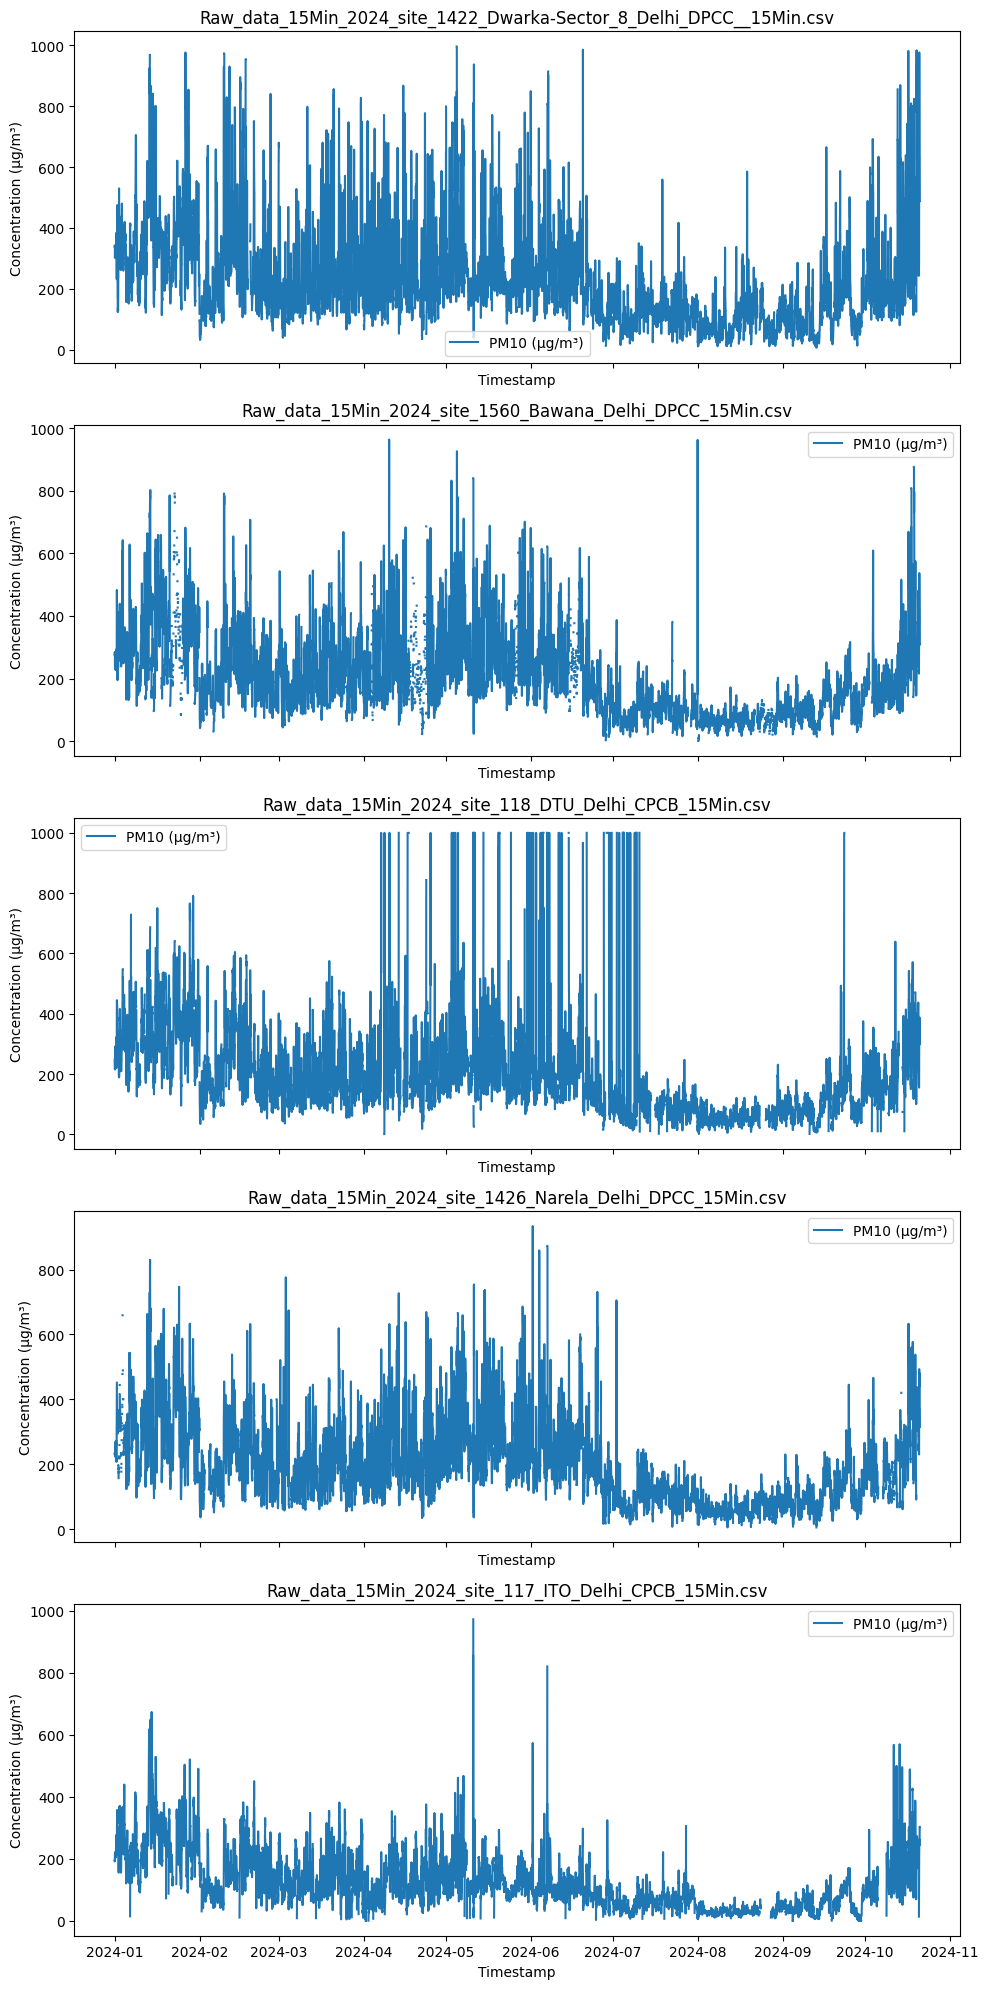

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def load_dataset_files(directory, extension=".csv"):
    """
    Load all files with a specific extension from a directory.
    """
    return [f for f in os.listdir(directory) if f.endswith(extension)]

def generate_null_report(files, directory, pollutants):
    """
    Generate a null values report for specified pollutants and sort files by null counts.
    """
    report = {}
    for f in files:
        file_path = os.path.join(directory, f)
        data = pd.read_csv(file_path)
        null_counts = {pollutant: data[pollutant].isnull().sum() for pollutant in pollutants}
        total_nulls = sum(null_counts.values())
        report[f] = {"null_counts": null_counts, "total_nulls": total_nulls}
    
    # Sort files by total null counts
    sorted_files = sorted(report.keys(), key=lambda x: report[x]["total_nulls"])
    return report, sorted_files

def visualize_pollutant_trends(files, directory, pollutant, n_plots=5):
    """
    Visualize trends for a specific pollutant in the top `n_plots` files with least null values.
    """
    files = files[:n_plots]
    fig, axes = plt.subplots(nrows=len(files), ncols=1, figsize=(10, 4 * len(files)), sharex=True)

    for i, f in enumerate(files):
        file_path = os.path.join(directory, f)
        data = pd.read_csv(file_path)
        data["Timestamp"] = pd.to_datetime(data["Timestamp"])
        data.set_index("Timestamp", inplace=True)

        axes[i].plot(data.index, data[pollutant], label=pollutant)
        axes[i].set_title(f)
        axes[i].set_xlabel("Timestamp")
        axes[i].set_ylabel("Concentration (µg/m³)")
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# Main Execution
if __name__ == "__main__":
    # Configuration
    directory = "Dataset_Dehli"
    pollutants = ["PM2.5 (µg/m³)", "PM10 (µg/m³)", "NO (µg/m³)", "NO2 (µg/m³)", "SO2 (µg/m³)", "CO (mg/m³)", "Ozone (µg/m³)"]
    pollutant_to_plot = pollutants[1]  # Pollutant to visualize trends

    # Step 1: Load dataset files
    files = load_dataset_files(directory)

    # Step 2: Generate null values report and sort files
    null_report, sorted_files = generate_null_report(files, directory, pollutants)
    
    # Print null values report
    for file, details in null_report.items():
        print(f"\nDataset: {file}")
        for pollutant, null_count in details["null_counts"].items():
            print(f"{pollutant}: {null_count} missing values")
        print(f"Total missing values: {details['total_nulls']}")

    print("\nSorted files by least null values:", sorted_files[:5]  )

    # Step 3: Visualize trends for the specified pollutant
    visualize_pollutant_trends(sorted_files, directory, pollutant_to_plot)


# Preprocess the least null values data

In [9]:
import numpy as np
#preprocess datasets in Non_Null_Datasets 
directory_name=r"C:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\Non_Null_Datasets"
datasets = os.listdir(directory_name)

for dataset in datasets:
    file_path = os.path.join(directory_name, dataset)
    df = pd.read_csv(file_path)
    #fill in missing values using inter quartile range
    numeric_cols = df.select_dtypes(include=[np.number])
    Q1 = numeric_cols.quantile(0.25)
    Q3 = numeric_cols.quantile(0.75)
    IQR = Q3 - Q1
    condition = ~((numeric_cols < (Q1 - 1.5 * IQR)) | (numeric_cols > (Q3 + 1.5 * IQR))).any(axis=1)
    df = df[condition]
    #drop duplicates
    df.drop_duplicates(inplace=True)
    #save the preprocessed data
    new_file_name = dataset.split('.')[0] + "_Preprocessed.csv"
    new_file_path = os.path.join(directory_name, new_file_name)
    print(f"Preprocessed {dataset} saved as {new_file_name}")
    df.to_csv(file_path, index=False)



Preprocessed Raw_data_15Min_2024_site_1434_Wazirpur_Delhi_DPCC_15Min.csv saved as Raw_data_15Min_2024_site_1434_Wazirpur_Delhi_DPCC_15Min_Preprocessed.csv
Preprocessed Raw_data_15Min_2024_site_1560_Bawana_Delhi_DPCC_15Min.csv saved as Raw_data_15Min_2024_site_1560_Bawana_Delhi_DPCC_15Min_Preprocessed.csv
Preprocessed Raw_data_15Min_2024_site_1561_Mundka_Delhi_DPCC_15Min.csv saved as Raw_data_15Min_2024_site_1561_Mundka_Delhi_DPCC_15Min_Preprocessed.csv
Preprocessed Raw_data_15Min_2024_site_1563_Pusa_Delhi_DPCC_15Min.csv saved as Raw_data_15Min_2024_site_1563_Pusa_Delhi_DPCC_15Min_Preprocessed.csv
Preprocessed Raw_data_15Min_2024_site_5024_Alipur_Delhi_DPCC_15Min.csv saved as Raw_data_15Min_2024_site_5024_Alipur_Delhi_DPCC_15Min_Preprocessed.csv


# Code to find the model
